In [1]:
import pandas as pd
import numpy as np
from functions import *
from sklearn.utils import shuffle
from tensorflow import keras
from keras.layers import Dense, Activation, Add, Softmax, Flatten, Normalization, Conv1D, MaxPooling1D
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from scipy.stats import mode
from sklearn.model_selection import train_test_split

X_train_orig = pd.read_csv('../data/X_train.csv', index_col='id')
X_train_filtered = filter_signal(X_train_orig)
X_test_orig = pd.read_csv('../data/X_test.csv', index_col='id')
X_test_filtered = filter_signal(X_test_orig)
y_train_orig = pd.read_csv('../data/y_train.csv', index_col='id')

In [2]:
def pad_data(data, to_pad, steps):
    padded = pd.DataFrame(np.ones((len(data),to_pad)))
    for i in range(len(data)):
        one_seq = data.iloc[i,0:to_pad].dropna()
        len_one_seq = len(one_seq)
        last_val = one_seq[-1]
        n = to_pad - len_one_seq
    
        to_concat = np.repeat(last_val, n)
        new_one_seq = np.concatenate([one_seq, to_concat])
        padded.iloc[i,:] = new_one_seq
    padded = padded.iloc[:,::steps]

    return padded

def get_beats(X, y, get_all, test_data):
    X_train_beats = np.empty((0, 180))
    y_train_beats = []
    index = []
    for i in range(len(X)):
        signal = X.iloc[i].dropna().to_numpy(dtype='float32')

        # get r peaks
        r_peaks = ecg.engzee_segmenter(signal, 300)['rpeaks']
        if get_all == True: # might want to not train on the weird heartbeats seems to give better result
            if len(r_peaks) == 0:
                r_peaks = ecg.ssf_segmenter(signal, 300)['rpeaks']
            elif len(r_peaks) == 0:
                r_peaks = ecg.hamilton_segmenter(signal, 300)['rpeaks']
            elif len(r_peaks) == 0:
                r_peaks = ecg.gamboa_segmenter(signal, 300)['rpeaks']

        # extract heartbeats
        beats = ecg.extract_heartbeats(signal, r_peaks, 300)['templates']
        temp1 = np.zeros((len(beats),180))
        for b in range(len(beats)):
            temp1[b,:] = beats[b]
            
        
        X_train_beats = np.vstack([X_train_beats, temp1])
        if test_data == False: # cant stack the true y for real test data
            y_train_beats = np.hstack([y_train_beats, np.repeat(y.iloc[i,0], len(beats))])
        elif test_data == True:
            y_train_beats = np.hstack([y_train_beats, np.repeat("NaN", len(beats))])
        index = np.hstack([index, np.repeat(i, len(beats))])

    # shuffle to prevent the same class to be clustered but only for train data
    if test_data == False:
        X_train_beats, y_train_beats, index = shuffle(X_train_beats, y_train_beats, index, random_state=42)

    return X_train_beats, y_train_beats, index

def agg_beats_predict(predict_beats, index):
    # returns mode prediction for beats of one observation
    predictions = np.argmax(predict_beats,axis=1)
    agg_beats_prediction = []
    for i in range(int(np.max(index))+1):
        prediction = predictions[index == i]
        agg_beats_prediction.append(mode(prediction)[0][0])

    return agg_beats_prediction
        
    

In [3]:
def make_CNN(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = keras.layers.Normalization()(input_layer)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    
    conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    conv4 = keras.layers.BatchNormalization()(conv4)
    conv4 = keras.layers.ReLU()(conv4)

    # conv5 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv4)
    # conv5 = keras.layers.BatchNormalization()(conv5)
    # conv5 = keras.layers.ReLU()(conv5)

    # conv6 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv5)
    # conv6 = keras.layers.BatchNormalization()(conv6)
    # conv6 = keras.layers.ReLU()(conv6)

    # conv7 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv6)
    # conv7 = keras.layers.BatchNormalization()(conv7)
    # conv7 = keras.layers.ReLU()(conv7)

    gap = keras.layers.GlobalAveragePooling1D()(conv4)

    dense1 = keras.layers.Dense(50, activation='relu')(gap)
    dense2 = keras.layers.Dense(50, activation='relu')(dense1)
    dropout2 = keras.layers.Dropout(0.5)(dense2)
    dense3 = keras.layers.Dense(50, activation='relu')(dropout2)
    # dropout = keras.layers.Dropout(0.5)(dense2)

    output_layer = keras.layers.Dense(4, activation="softmax")(dense3)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [4]:
def make_arvix(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)
    C = Conv1D(filters=32, kernel_size=5, strides=1)(normalisation_layer)

    C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
    A11 = Activation("relu")(C11)
    C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
    S11 = Add()([C12, C])
    A12 = Activation("relu")(S11)
    M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


    C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
    A21 = Activation("relu")(C21)
    C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
    S21 = Add()([C22, M11])
    A22 = Activation("relu")(S21) # S21?
    M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


    C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
    A31 = Activation("relu")(C31)
    C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
    S31 = Add()([C32, M21])
    A32 = Activation("relu")(S31)
    M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


    C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
    A41 = Activation("relu")(C41)
    C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
    S41 = Add()([C42, M31])
    A42 = Activation("relu")(S41)
    M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


    C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
    A51 = Activation("relu")(C51)
    C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
    S51 = Add()([C52, M41])
    A52 = Activation("relu")(S51)
    M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

    F1 = Flatten()(M51)

    D1 = Dense(32)(F1)
    A6 = Activation("relu")(D1)
    D2 = Dense(32)(A6)
    D3 = Dense(4)(D2)
    output_layer = Softmax()(D3)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [5]:
#Padding the sequence with the values in last row to max length
to_pad = 8400 # cut the sequence and impute the missing entries until all have this length
steps = 20 # to reduce time series length on every timepoint is taken
# split = 4000 # to create test set with known label

# choose the data to actually train on (after padding)
X_train = X_train_filtered 
X_test = X_test_filtered
y_train = y_train_orig

In [6]:
# shuffle data
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# # creat test set with labels
# test = X_train.iloc[split:,:] 
# test_target = y_train.iloc[split:,:]
# train = X_train.iloc[:split,:] 
# train_target = y_train.iloc[:split]

# alternative
from sklearn.model_selection import train_test_split
train, test, train_target, test_target = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Full time series

In [7]:
# apply needed data transformation
train_padded = pad_data(train, to_pad, steps)
test_padded = pad_data(test, to_pad, steps)

# get data in right dimension
train_padded = np.array(train_padded).reshape((train_padded.shape[0], train_padded.shape[1], 1))
test_padded = np.array(test_padded).reshape((test_padded.shape[0], test_padded.shape[1], 1))

In [8]:
model_timeseries= make_CNN(input_shape=train_padded.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
# model_timeseries.summary()

epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model_timeseries.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model_timeseries.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history_timeseries = model_timeseries.fit(
    train_padded,
    train_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

2021-12-06 13:00:10.711755: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2021-12-06 13:00:10.711869: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2021-12-06 13:00:10.893562: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2021-12-06 13:00:10.894729: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

Epoch 1/500


2021-12-06 13:00:11.205486: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


103/103 [==============================] - ETA: 0s - loss: 1.8582 - sparse_categorical_accuracy: 0.5870

2021-12-06 13:00:13.552098: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


103/103 [==============================] - 3s 22ms/step - loss: 1.8582 - sparse_categorical_accuracy: 0.5870 - val_loss: 1.2935 - val_sparse_categorical_accuracy: 0.6093
Epoch 2/500
103/103 [==============================] - 2s 19ms/step - loss: 1.1149 - sparse_categorical_accuracy: 0.5984 - val_loss: 1.3904 - val_sparse_categorical_accuracy: 0.3761
Epoch 3/500
103/103 [==============================] - 2s 18ms/step - loss: 0.9885 - sparse_categorical_accuracy: 0.6185 - val_loss: 1.1127 - val_sparse_categorical_accuracy: 0.6117
Epoch 4/500
103/103 [==============================] - 2s 19ms/step - loss: 0.9368 - sparse_categorical_accuracy: 0.6231 - val_loss: 0.9636 - val_sparse_categorical_accuracy: 0.6129
Epoch 5/500
103/103 [==============================] - 2s 19ms/step - loss: 0.9469 - sparse_categorical_accuracy: 0.6246 - val_loss: 0.9592 - val_sparse_categorical_accuracy: 0.6422
Epoch 6/500
103/103 [==============================] - 2s 19ms/step - loss: 0.9161 - sparse_categorica

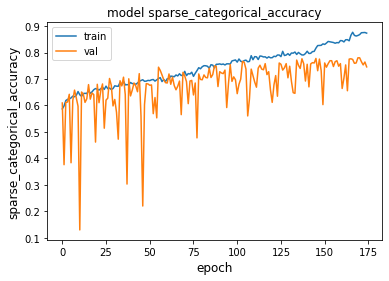

In [9]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history_timeseries.history[metric])
plt.plot(history_timeseries.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [10]:
model_timeseries = keras.models.load_model("best_model_timeseries.h5")

# Accuracy
test_loss, test_acc = model_timeseries.evaluate(test_padded,test_target)
print("Test accuracy", test_acc)
print("Test loss", test_loss)

# F1 Score
predict_timesseries=model_timeseries.predict(test_padded) 
classes_timeseries=np.argmax(predict_timesseries,axis=1)
print("F1 Score: ", f1_score(test_target, classes_timeseries, average='micro'))

# Details
print(classification_report(test_target, classes_timeseries))
print("Confusion Matrix:\n", confusion_matrix(test_target, classes_timeseries))

16/32 [==============>...............] - ETA: 0s - loss: 0.6746 - sparse_categorical_accuracy: 0.7598

2021-12-06 13:05:48.297521: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


32/32 [==============================] - 0s 7ms/step - loss: 0.6809 - sparse_categorical_accuracy: 0.7588
Test accuracy 0.7587890625
Test loss 0.6809249520301819
F1 Score:  0.7587890625
              precision    recall  f1-score   support

           0       0.78      0.94      0.85       612
           1       0.67      0.60      0.64        81
           2       0.71      0.47      0.56       290
           3       0.82      0.44      0.57        41

    accuracy                           0.76      1024
   macro avg       0.74      0.61      0.66      1024
weighted avg       0.75      0.76      0.74      1024

Confusion Matrix:
 [[575   6  29   2]
 [ 10  49  22   0]
 [136  17 135   2]
 [ 17   1   5  18]]


2021-12-06 13:05:48.655316: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


# Individual heartbeats

In [11]:
# apply needed data transformation
train_beats, train_beats_target, train_beats_index = get_beats(train, train_target, False, False)
test_beats, test_beats_target, test_beats_index = get_beats(test, test_target, True, False)

# get data in right dimension
train_beats = np.expand_dims(train_beats, 2)
test_beats = np.expand_dims(test_beats, 2)

In [14]:
model_beats = keras.models.load_model("best_model.h5")

# Accuracy 
test_loss, test_acc = model_beats.evaluate(test_beats,test_beats_target)
print("Test accuracy", test_acc)
print("Test loss", test_loss)

# F1 Score
predict_beats=model_beats.predict(test_beats) 
classes_beats=np.argmax(predict_beats,axis=1)
print("F1 Score: ", f1_score(test_beats_target, classes_beats, average='micro'))

# Details
print(classification_report(test_beats_target, classes_beats))
print("Confusion Matrix:\n", confusion_matrix(test_beats_target, classes_beats))

# if aggregate all predictions per observation
agg_beats_prediction = agg_beats_predict(predict_beats, test_beats_index)
print("F1 Score of aggregate prediction: ", f1_score(test_target, agg_beats_prediction, average='micro'))

  10/1140 [..............................] - ETA: 6s - loss: 0.4968 - sparse_categorical_accuracy: 0.7969  

2021-12-06 13:10:15.666439: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


1140/1140 [==============================] - 6s 6ms/step - loss: 0.5961 - sparse_categorical_accuracy: 0.7730
Test accuracy 0.772969126701355
Test loss 0.5961005091667175


2021-12-06 13:10:22.140252: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


F1 Score:  0.7729691185343646
              precision    recall  f1-score   support

         0.0       0.78      0.91      0.84     20773
         1.0       0.74      0.64      0.69      3685
         2.0       0.79      0.59      0.68     10842
         3.0       0.51      0.38      0.44      1162

    accuracy                           0.77     36462
   macro avg       0.70      0.63      0.66     36462
weighted avg       0.77      0.77      0.76     36462

Confusion Matrix:
 [[18927   423  1147   276]
 [  798  2369   478    40]
 [ 3903   376  6442   121]
 [  579    30   107   446]]
F1 Score of aggregate prediction:  0.8173828125


# Combine both predictions

In [15]:
# predictions = np.argmax(predict_beats,axis=1)
agg_mean_beats_prediction = np.zeros((len(test_target), 4))
for i in range(int(np.max(test_beats_index))+1):
    prediction = predict_beats[test_beats_index == i]
    agg_mean_beats_prediction[i,:] = np.mean(prediction, axis=0)

In [16]:
predict_combine = np.add(agg_mean_beats_prediction, predict_timesseries)/2
classes_combine = np.argmax(predict_combine,axis=1)
print(classification_report(test_target, classes_combine))

              precision    recall  f1-score   support

           0       0.80      0.97      0.88       612
           1       0.84      0.72      0.77        81
           2       0.85      0.55      0.67       290
           3       0.94      0.41      0.58        41

    accuracy                           0.81      1024
   macro avg       0.86      0.66      0.72      1024
weighted avg       0.82      0.81      0.80      1024



In [17]:
predict_beats_train = model_beats.predict(train_beats) 
agg_mean_beats_prediction_train = np.zeros((len(train_target), 4))
for i in range(int(np.max(train_beats_index))+1):
    prediction = predict_beats_train[train_beats_index == i]
    agg_mean_beats_prediction_train[i,:] = np.mean(prediction, axis=0)

predict_timesseries_train = model_timeseries.predict(train_padded) 


# train xgboost on the probabilities
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, KFold

predict_xgb_train = np.hstack([predict_timesseries_train, agg_mean_beats_prediction_train])

xgb = XGBClassifier(n_estimators=1000, eta = 0.1, objective='multi:softmax' , use_label_encoder=False, eval_metric='mlogloss') 
crossvalidation = KFold(n_splits=10, shuffle=True, random_state=42)
xgb_score = np.mean(cross_val_score(xgb, predict_xgb_train, np.ravel(train_target), scoring="f1_micro", cv=crossvalidation, n_jobs=-1))
print("A combined XGBoost model achieves an F1 score of: ", xgb_score)

xgb_fit = xgb.fit(predict_xgb_train, np.ravel(train_target))

/Users/juliusc/miniforge3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3372: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/juliusc/miniforge3/lib/python3.9/site-packages/numpy/core/_methods.py:162: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(
2021-12-06 13:10:39.296474: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


A combined XGBoost model achieves an F1 score of:  0.8834623412248792


In [18]:
# xgb_fit = xgb.fit(predict_xgb_train, np.ravel(train_target))

# predict test set
predict_xgb_test = np.hstack([predict_timesseries, agg_mean_beats_prediction])
test_set_predict_xgb = xgb.predict(predict_xgb_test)

# classes_beats=np.argmax(test_set_predict_xgb,axis=1)
print("F1 Score: ", f1_score(test_target, test_set_predict_xgb, average='micro'))

F1 Score:  0.8681640625


# Make prediction for real test set

In [19]:
model_timeseries = keras.models.load_model("best_model_timeseries.h5")
model_beats = keras.models.load_model("best_model.h5")


# make test data
X_test_padded = pad_data(X_test, to_pad, steps)
X_test_beats, X_test_beats_target, X_test_beats_index = get_beats(X_test, np.zeros(len(X_test)), True, True)
# expand data
X_test_padded = np.expand_dims(X_test_padded, 2)
X_test_beats = np.expand_dims(X_test_beats, 2)


# make prediction
predict_timesseries_final=model_timeseries.predict(X_test_padded) 
predict_beats_final=model_beats.predict(X_test_beats) 
# aggregate beats predictions
agg_mean_beats_prediction_final = np.zeros((len(X_test), 4))
for i in range(int(np.max(X_test_beats_index))+1):
    prediction = predict_beats_final[X_test_beats_index == i]
    agg_mean_beats_prediction_final[i,:] = np.mean(prediction, axis=0)


# use xgb to make final prediction
predict_xgb_final = np.hstack([predict_timesseries_final, agg_mean_beats_prediction_final])
xgb_final_prediction = xgb_fit.predict(predict_xgb_final)

2021-12-06 13:19:02.720711: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.
2021-12-06 13:19:03.173066: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


In [20]:
# final prediction
y_test_final = pd.DataFrame({'id' : range(X_test.shape[0])}) 
y_test_final['y'] = xgb_final_prediction
y_test_final.to_csv('../out/y_test_xgb.csv', index=False)

In [21]:
print(y_test_final['y'].value_counts())

0    2058
2     936
1     304
3     113
Name: y, dtype: int64


# Last Resort

In [22]:
predict_beats_to_agg_mode = model_beats.predict(X_test_beats) 
agg_beats_prediction_mode = agg_beats_predict(predict_beats_to_agg_mode, X_test_beats_index)
# final prediction
y_test_final = pd.DataFrame({'id' : range(X_test.shape[0])}) 
y_test_final['y'] = agg_beats_prediction_mode
y_test_final.to_csv('../out/y_test_last_resort.csv', index=False)